In [ ]:
# A simple polynomial fit code (linear regression) using gradient descent
# the same as leastquare code except that we use pytorch nn library as much as we can.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [3]:
# generate a y = x^2 curve with x being uniform random using 6 points
# add small Gaussian errors in y, then make a plot
# using stack, we generate the design matrix X = x_poly
x = torch.rand((6))-0.5
y = x*x + 0.01*torch.randn_like(x)
x_poly = torch.stack([1.0*x**0,x,x**2],dim=1)

In [5]:
x_poly.shape

torch.Size([6, 3])

In [7]:
# define the model class: coefficients of the polynomial in nn.Linear as Parameter() 
# which automatically have requires_grad = True.
# x =(1,x,x^2, ..., x^n-1) in forward is the feature vector. The fitting class by
# forward() return y = x W^T.

class fitting(nn.Module):
    def __init__(self,n):
        super().__init__()
        self.layer = nn.Linear(n,1,bias=False)

    def forward(self,x):
        return self.layer(x)

In [9]:
# setup the model, etc.  3 means quadratic fit with (1, x, x^2) as basis
# use mean-square-error as loss function
# pass the learnable parameters from the model to stochastic gradient descent
# optimization code, and set learning rate to 0.01.
# We instantiate the objects from these classes.
model = fitting(3)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.1)

In [11]:
# training loop
# The return value yhat is 6x1,
# so in order to match y, I must flatten yhat as 1D array
for epoch in range(10000):
    yhat = model(x_poly)
    yhat = torch.flatten(yhat)
    loss = criterion(yhat,y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# extract weight w
w = torch.flatten(model.layer.weight).detach().numpy()

print(loss)
print(w)

tensor(7.1737e-05, grad_fn=<MseLossBackward0>)
[-0.00460262 -0.03717481  1.0259595 ]


In [13]:
# print out the fitting parameter as w in model parameters
# assign to w as 1D numpy array
for p in model.named_parameters():
    print(p)

('layer.weight', Parameter containing:
tensor([[-0.0046, -0.0372,  1.0260]], requires_grad=True))


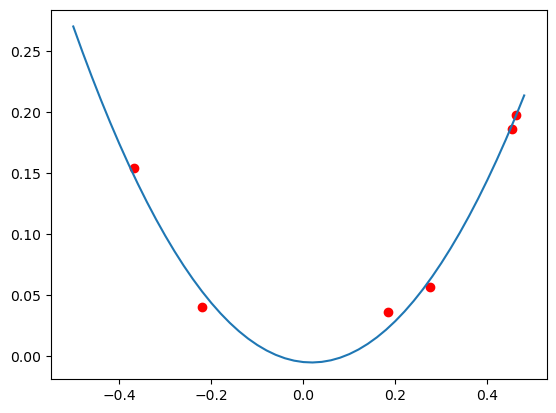

In [15]:
# the fit defines a function for plotting, using 
# the w found by SGD.
def fit(x,w):
    yval = 0.0
    for i in range(len(w)):
        yval += w[i]*(x**i)
    return yval

plt.scatter(x.numpy(), y.numpy(),marker='o',color='red')
xfit = np.arange(-0.5,0.5,0.02)
yfit = xfit.copy()
for i in range(len(xfit)):
    xval = xfit[i]
    yfit[i] = fit(xval,w)
plt.plot(xfit,yfit)

In [ ]:
# compare with exact solution yhat = (X^T X)^(-1) X^T y.  

In [23]:
XT = x_poly.T
theta = torch.linalg.inv(XT @ x_poly) @ (XT @ y)
print("theta exact=",theta.numpy())
print("w=", w)

theta exact= [-0.00466753 -0.03724376  1.0265818 ]
w= [-0.00460262 -0.03717481  1.0259595 ]
